In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Match_Predictor/data/processed/cleaned.csv")

In [3]:
data.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season
0,E0,2022-08-05,20:00,Crystal Palace,Arsenal,0,2,A,0,1,...,0.50,2.09,1.84,2.04,1.88,2.09,1.88,2.03,1.85,2022/2023
1,E0,2022-08-06,12:30,Fulham,Liverpool,2,2,D,1,0,...,1.75,1.90,2.03,1.91,2.02,2.01,2.06,1.89,1.99,2022/2023
2,E0,2022-08-06,15:00,Bournemouth,Aston Villa,2,0,H,1,0,...,0.50,1.93,2.00,1.93,2.00,1.94,2.04,1.88,2.00,2022/2023
3,E0,2022-08-06,15:00,Leeds,Wolves,2,1,H,1,1,...,-0.25,2.08,1.85,2.10,1.84,2.14,1.87,2.08,1.81,2022/2023
4,E0,2022-08-06,15:00,Newcastle,Nott'm Forest,2,0,H,0,0,...,-1.00,1.97,1.96,1.99,1.93,2.19,1.97,2.03,1.86,2022/2023


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 89 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Div        1520 non-null   object 
 1   Date       1520 non-null   object 
 2   Time       1520 non-null   object 
 3   HomeTeam   1520 non-null   object 
 4   AwayTeam   1520 non-null   object 
 5   FTHG       1520 non-null   int64  
 6   FTAG       1520 non-null   int64  
 7   FTR        1520 non-null   object 
 8   HTHG       1520 non-null   int64  
 9   HTAG       1520 non-null   int64  
 10  HTR        1520 non-null   object 
 11  Referee    1520 non-null   object 
 12  HS         1520 non-null   int64  
 13  AS         1520 non-null   int64  
 14  HST        1520 non-null   int64  
 15  AST        1520 non-null   int64  
 16  HF         1520 non-null   int64  
 17  AF         1520 non-null   int64  
 18  HC         1520 non-null   int64  
 19  AC         1520 non-null   int64  
 20  HY      

In [5]:
data['HomeTeam'].unique()

array(['Crystal Palace', 'Fulham', 'Bournemouth', 'Leeds', 'Newcastle',
       'Tottenham', 'Everton', 'Leicester', 'Man United', 'West Ham',
       'Brentford', 'Wolves', 'Southampton', 'Arsenal', 'Brighton',
       'Aston Villa', 'Man City', "Nott'm Forest", 'Chelsea', 'Liverpool',
       'Burnley', 'Sheffield United', 'Luton', 'Ipswich', 'Sunderland'],
      dtype=object)

In [6]:
data['Season'].unique()

array(['2022/2023', '2023/2024', '2024/2025', '2025/2026'], dtype=object)

In [7]:
data['Season'].value_counts()

Season
2022/2023    380
2023/2024    380
2024/2025    380
2025/2026    380
Name: count, dtype: int64

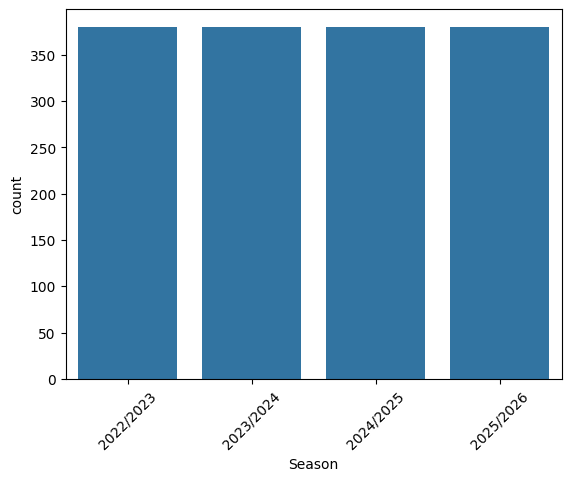

In [8]:
sns.countplot(
    data=data,
    x="Season"
)

plt.xticks(rotation=45)
plt.show()

#### Checking to see the distribution for wins, losses and draws

In [10]:
data['FTR'].value_counts()

FTR
H    676
A    478
D    366
Name: count, dtype: int64

#### Checking the percentage for wins, losses and draws

In [12]:
season_win = pd.crosstab(data['Season'], data['FTR'], normalize='index')*100

In [13]:
season_win

FTR,A,D,H
Season,,,
2022/2023,28.684211,22.894737,48.421053
2023/2024,32.368421,21.578947,46.052632
2024/2025,34.736842,24.473684,40.789474
2025/2026,30.000000,27.368421,42.631579


<Figure size 600x600 with 0 Axes>

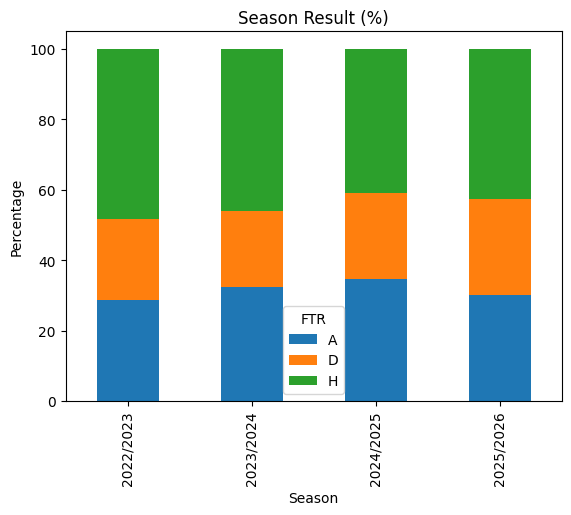

In [14]:
plt.figure(figsize=(6,6))
season_win.plot(kind='bar', stacked=True)
plt.title("Season Result (%)")
plt.ylabel("Percentage")
plt.show()

In [15]:
data['FTR'].value_counts(normalize=True)*100

FTR
H    44.473684
A    31.447368
D    24.078947
Name: proportion, dtype: float64

In [16]:
rates = data['FTR'].value_counts(normalize=True)

home_win_rate = rates.get('H', 0) * 100
away_win_rate = rates.get('A', 0) * 100
draw_rate = rates.get('D', 0) * 100

print(f"Home Win Rate: {home_win_rate:.2f}%")
print(f"Away Win Rate: {away_win_rate:.2f}%")
print(f"Draw Rate: {draw_rate:.2f}%")

Home Win Rate: 44.47%
Away Win Rate: 31.45%
Draw Rate: 24.08%


In [17]:
# is_home_team
# home_advantage_score

#### Average home goals?
#### Average away goals?
#### Outliers?
#### Skewness?

In [19]:
data["FTAG"].describe()

count    1520.000000
mean        1.335526
std         1.190505
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: FTAG, dtype: float64

In [20]:
data["FTHG"].describe()

count    1520.000000
mean        1.618421
std         1.315498
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: FTHG, dtype: float64

<Axes: ylabel='FTAG'>

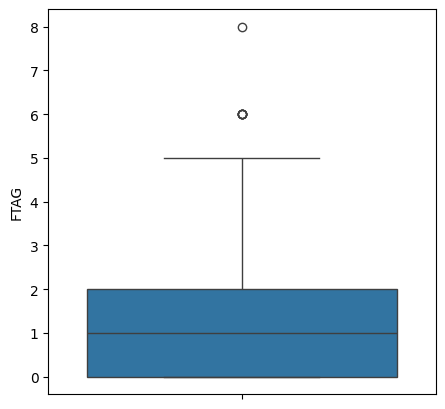

In [21]:
plt.figure(figsize=(5,5))
sns.boxplot(data, y=data['FTAG'])

<Axes: ylabel='FTHG'>

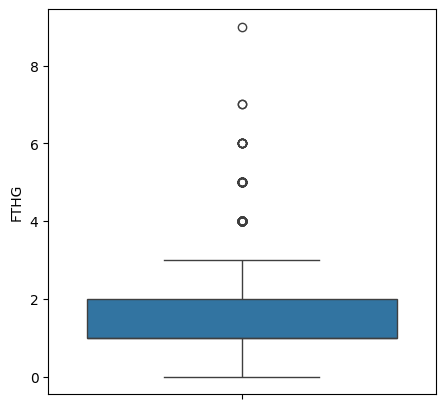

In [22]:
plt.figure(figsize=(5,5))
sns.boxplot(data, y=data['FTHG'])

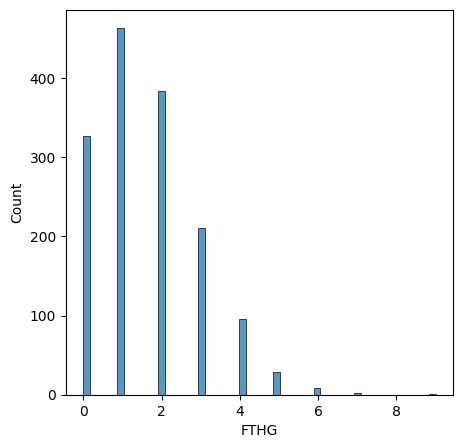

In [23]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['FTHG'])
plt.show()

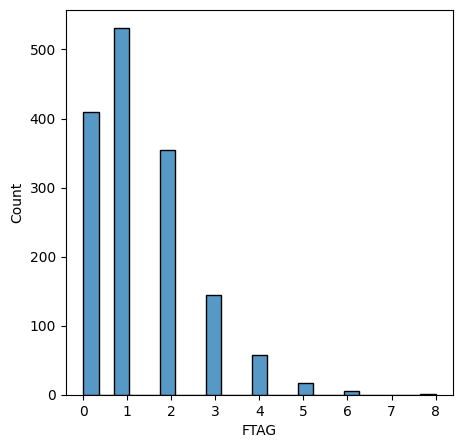

In [24]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['FTAG'])
plt.show()

##### How common are high-scoring matches?
#### Distribution?

In [26]:
data["TotalGoals"] = (
    data["FTHG"] + data["FTAG"]
)

In [27]:
data[["FTHG", "FTAG", "TotalGoals"]].head()

,FTHG,FTAG,TotalGoals
0,0,2,2
1,2,2,4
2,2,0,2
3,2,1,3
4,2,0,2


In [28]:
data["TotalGoals"].describe()

count    1520.000000
mean        2.953947
std         1.671268
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: TotalGoals, dtype: float64

In [174]:
data[(data['FTAG'] == 8) | (data['FTHG'] == 9)]

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,TotalGoals,Over2.5,TotalCorners,TotalFouls
33,E0,2022-08-27,15:00,Liverpool,Bournemouth,9,0,H,5,0,...,1.97,1.95,2.27,1.87,2.01,2022/2023,9,1,9,11
438,E0,2023-09-24,16:30,Sheffield United,Newcastle,0,8,A,0,3,...,1.98,2.08,1.99,1.98,1.89,2023/2024,8,1,8,20


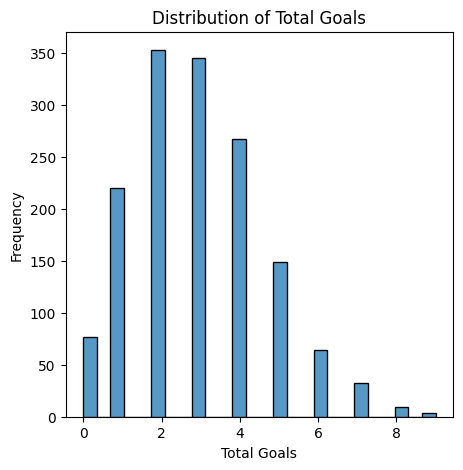

In [30]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['TotalGoals'])
plt.title("Distribution of Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()

Most matches have between 1 and 4 goals

In [32]:
goal_counts = (
    data["TotalGoals"]
    .value_counts()
    .sort_index()
)

print(goal_counts)

TotalGoals
0     77
1    220
2    353
3    345
4    267
5    149
6     64
7     32
8      9
9      4
Name: count, dtype: int64


In [33]:
data["Over2.5"] = (
    data["TotalGoals"] > 2
).astype(int)

In [34]:
data["Over2.5"].value_counts(normalize=True)*100

Over2.5
1    57.236842
0    42.763158
Name: proportion, dtype: float64

In [176]:
over_2_season = pd.crosstab(data['Season'], data['Over2.5'], normalize='index')*100

In [178]:
over_2_season

Over2.5,0,1
Season,,
2022/2023,47.368421,52.631579
2023/2024,35.263158,64.736842
2024/2025,43.421053,56.578947
2025/2026,45.000000,55.000000


Based on the cross tabulation done above, it can be seen that the season 2023/2024 has the highest percentage for 3 goals and above

In [198]:
home_data = data[['HomeTeam', 'Over2.5']].rename(columns={'HomeTeam': 'Team'})
away_data = data[['AwayTeam', 'Over2.5']].rename(columns={'AwayTeam': 'Team'})
all_games = pd.concat([home_data, away_data])

In [200]:
over_team_season = pd.crosstab(all_games['Team'], all_games['Over2.5'], normalize='index')*100

In [202]:
over_team_season

Over2.5,0,1
Team,,
Arsenal,42.763158,57.236842
Aston Villa,41.447368,58.552632
Bournemouth,42.763158,57.236842
Brentford,44.078947,55.921053
Brighton,38.157895,61.842105
Burnley,44.736842,55.263158
Chelsea,41.447368,58.552632
Crystal Palace,51.315789,48.684211
Everton,58.552632,41.447368


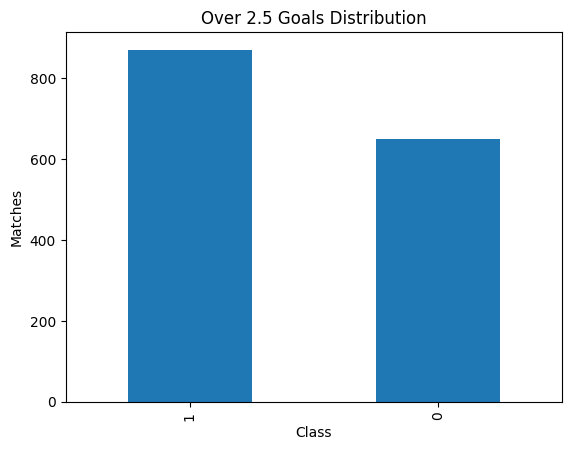

In [36]:
data["Over2.5"].value_counts().plot(
    kind="bar"
)

plt.title("Over 2.5 Goals Distribution")
plt.xlabel("Class")
plt.ylabel("Matches")

plt.show()

In [37]:
season_over25 = (
    data.groupby("Season")["Over2.5"]
      .mean()
      * 100
)

print(season_over25)

Season
2022/2023    52.631579
2023/2024    64.736842
2024/2025    56.578947
2025/2026    55.000000
Name: Over2.5, dtype: float64


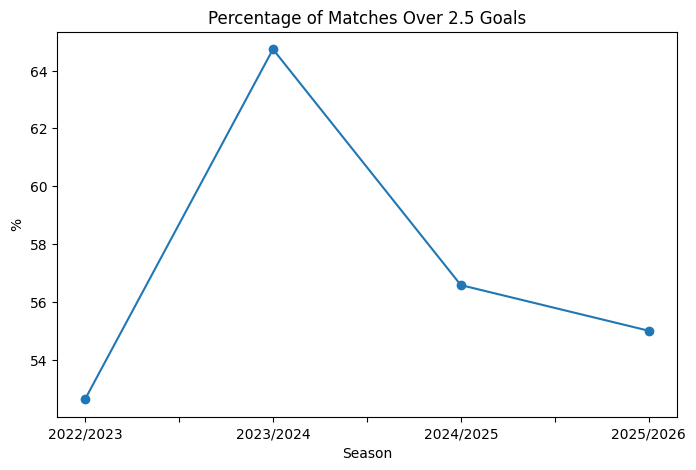

In [38]:
season_over25.plot(
    marker="o",
    figsize=(8,5)
)

plt.title(
    "Percentage of Matches Over 2.5 Goals"
)

plt.ylabel("%")

plt.show()

In [39]:
data.groupby("Season")["Over2.5"].value_counts()

Season     Over2.5
2022/2023  1          200
           0          180
2023/2024  1          246
           0          134
2024/2025  1          215
           0          165
2025/2026  1          209
           0          171
Name: count, dtype: int64

### Team Analysis
Which teams are involved in high scoring matches?

In [41]:
home_goals = (data.groupby('HomeTeam')["TotalGoals"].mean())

away_goals = (data.groupby('AwayTeam')['TotalGoals'].mean())

team_goals_avg = (home_goals + away_goals) / 2
team_goals_avg.sort_values(ascending=False).head(10)

HomeTeam
Sheffield United    3.657895
Luton               3.605263
Tottenham           3.302632
Liverpool           3.236842
Man City            3.190789
Ipswich             3.105263
Newcastle           3.098684
Brighton            3.059211
Leicester           3.052632
Burnley             3.052632
Name: TotalGoals, dtype: float64

In [42]:
# team_avg_df = team_goals_avg.reset_index()  # Convert Series to DataFrame
# team_avg_df.columns = ['HomeTeam', 'team_goals_avg']  # Rename columns

# # Merge with data to get Season
# result = data[['Season', 'HomeTeam']].drop_duplicates().merge(team_avg_df, on='HomeTeam')
# result.groupby('Season')['team_goals_avg'].mean().sort_values(ascending=False).head(10)

### CORNERS ANALYSIS

In [44]:
data['TotalCorners'] = data["HC"] + data["AC"]

In [45]:
data['TotalCorners'].describe()

count    1520.000000
mean       10.309868
std         3.393353
min         2.000000
25%         8.000000
50%        10.000000
75%        13.000000
max        21.000000
Name: TotalCorners, dtype: float64

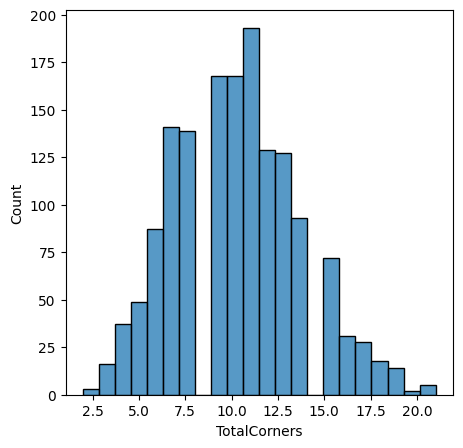

In [46]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['TotalCorners'])
plt.show()

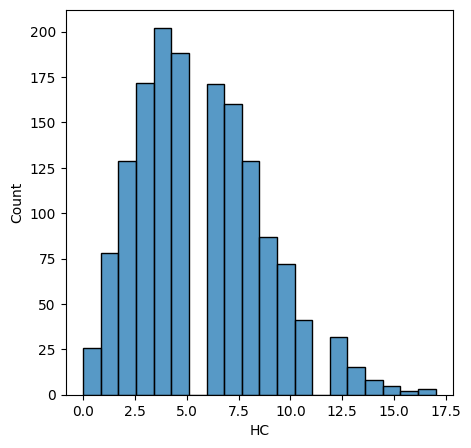

In [47]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['HC'])
plt.show()

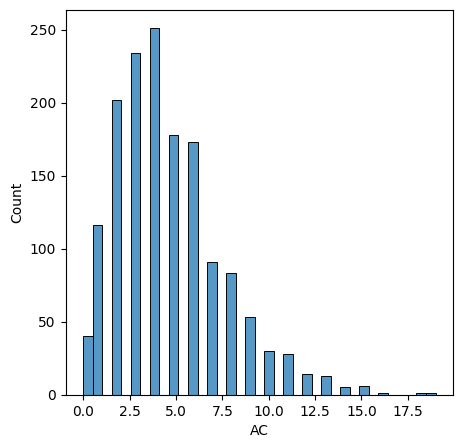

In [48]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['AC'])
plt.show()

#### High-corner teams?
##### Home corner advantage?

In [50]:
# Home corners earned
home_corners = (
    data.groupby("HomeTeam")["HC"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "HomeTeam": "Team",
              "HC": "Corners"
          }
      )
)

# Away corners earned
away_corners = (
    data.groupby("AwayTeam")["AC"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "AwayTeam": "Team",
              "AC": "Corners"
          }
      )
)

# Combine
team_corners = pd.concat(
    [home_corners, away_corners]
)

# Total corners per team
team_corners = (
    team_corners.groupby("Team")["Corners"]
                .sum()
                .sort_values(ascending=False)
)

print(team_corners.head(10))

Team
Man City       1022
Liverpool      1008
Arsenal         946
Newcastle       912
Tottenham       889
Chelsea         879
Aston Villa     829
Bournemouth     821
Brighton        813
Man United      803
Name: Corners, dtype: int64


In [206]:
home_corners_data = data[['HomeTeam', 'HC']].rename(columns={'HomeTeam': 'Team', 'HC': 'Corners'})
away_corners_data = data[['AwayTeam', 'AC']].rename(columns={'AwayTeam': 'Team', 'AC': 'Corners'})
all_corners = pd.concat([home_corners_data, away_corners_data])

# Now create a categorical variable for corner ranges (e.g., Over/Under 10.5 corners)
all_corners['CornerCategory'] = (all_corners['Corners'] > 10.5).map({True: 'Over10.5', False: 'Under10.5'})

# Calculate percentage of matches with over 10.5 corners by team
over_corner_season = pd.crosstab(all_corners['Team'], all_corners['CornerCategory'], normalize='index') * 100
print(over_corner_season.head(10))

CornerCategory   Over10.5   Under10.5
Team                                 
Arsenal         10.526316   89.473684
Aston Villa      7.236842   92.763158
Bournemouth      6.578947   93.421053
Brentford        1.315789   98.684211
Brighton         5.263158   94.736842
Burnley          1.315789   98.684211
Chelsea          7.236842   92.763158
Crystal Palace   3.289474   96.710526
Everton          0.000000  100.000000
Fulham           6.578947   93.421053


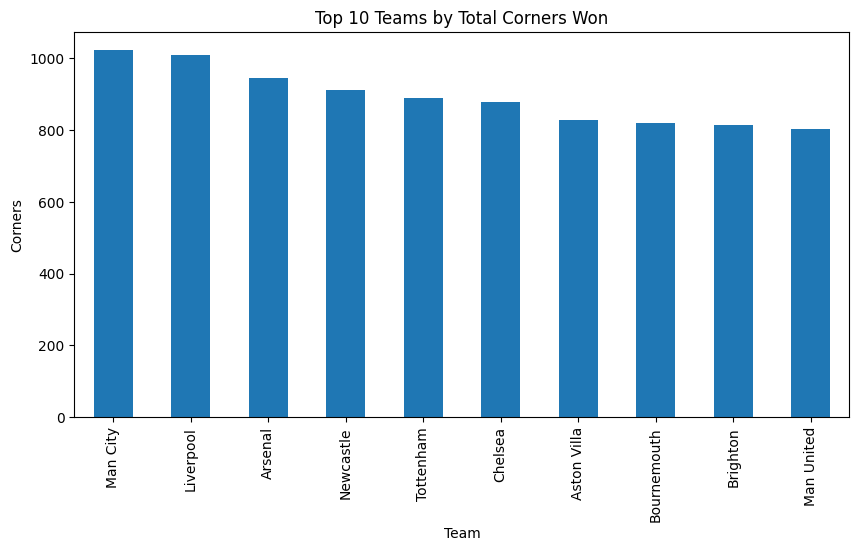

In [51]:
team_corners.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Teams by Total Corners Won")
plt.ylabel("Corners")
plt.show()

### AVERAGE CORNERS PER MATCHES

In [53]:
home_matches = data["HomeTeam"].value_counts()

away_matches = data["AwayTeam"].value_counts()

matches_played = (
    home_matches + away_matches
)

avg_corners = (
    team_corners / matches_played
).sort_values(
    ascending=False
)

avg_corners.head(10)

Man City       6.723684
Liverpool      6.631579
Arsenal        6.223684
Newcastle      6.000000
Tottenham      5.848684
Chelsea        5.782895
Aston Villa    5.453947
Bournemouth    5.401316
Luton          5.368421
Brighton       5.348684
dtype: float64

### Compare Home vs Away Corner Means

###### Do teams earn more corners when playing at home?

In [56]:
home_corner_mean = data['HC'].mean()
away_corner_mean = data['AC'].mean()

print("Home corner average is: ", home_corner_mean)
print("Away corner average is: ", away_corner_mean)

Home corner average is:  5.645394736842105
Away corner average is:  4.6644736842105265


From the averages above, it can be seen that home teams tend to slightly have an advantage over away teams in terms of corners.

Home teams earn approximately an  extra cornes per match.

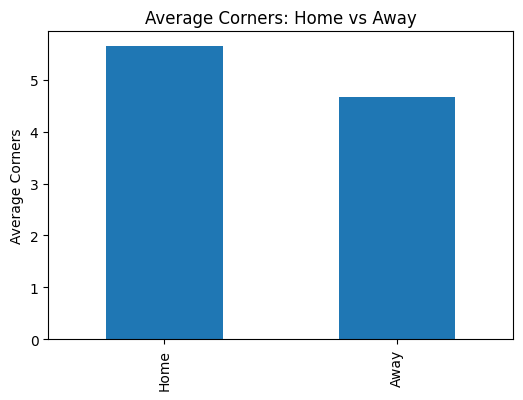

In [58]:
corner_means = pd.Series({
    "Home": data["HC"].mean(),
    "Away": data["AC"].mean()
})

corner_means.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Corners: Home vs Away")
plt.ylabel("Average Corners")
plt.show()

### CHECKING FOR TEAM SPECIFIC HOME ADVANTAGE

In [60]:
home_avg = (
    data.groupby("HomeTeam")["HC"]
      .mean()
)

away_avg = (
    data.groupby("AwayTeam")["AC"]
      .mean()
)

corner_advantage = (
    home_avg - away_avg
).sort_values(
    ascending=False
)

corner_advantage.head(10)

HomeTeam
Luton          2.526316
Man United     1.750000
Leeds          1.710526
Tottenham      1.644737
Newcastle      1.526316
Brighton       1.460526
Man City       1.342105
Chelsea        1.223684
Arsenal        1.105263
Bournemouth    1.039474
dtype: float64

#### Is the difference between home and away corners statistically significant?

In [62]:
t_stat, p_value = ttest_ind(
    data["HC"],
    data["AC"]
)

print("p-value:", p_value)

p-value: 1.7635384527478308e-19


Based on the value from the p-value there is overwhelming evidence of a statistically significant relationship/effect.

### FOULS ANALYSIS

Which teams foul most?
Home vs away foul differences?

In [66]:
data['TotalFouls'] = data['HF'] + data['AF']

In [67]:
# Home fouls earned
home_fouls = (
    data.groupby("HomeTeam")["HF"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "HomeTeam": "Team",
              "HF": "Fouls"
          }
      )
)

# Away fouls earned
away_fouls = (
    data.groupby("AwayTeam")["AF"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "AwayTeam": "Team",
              "AF": "Fouls"
          }
      )
)

# Combine
team_fouls = pd.concat(
    [home_fouls, away_fouls]
)

team_fouls = (
    team_fouls.groupby("Team")["Fouls"]
              .sum()
              .sort_values(ascending=False)
)

print(team_fouls.head(10))

Team
Wolves            1914
Bournemouth       1868
Tottenham         1757
Brighton          1731
Crystal Palace    1717
Chelsea           1704
Everton           1688
Liverpool         1680
Nott'm Forest     1671
Fulham            1641
Name: Fouls, dtype: int64


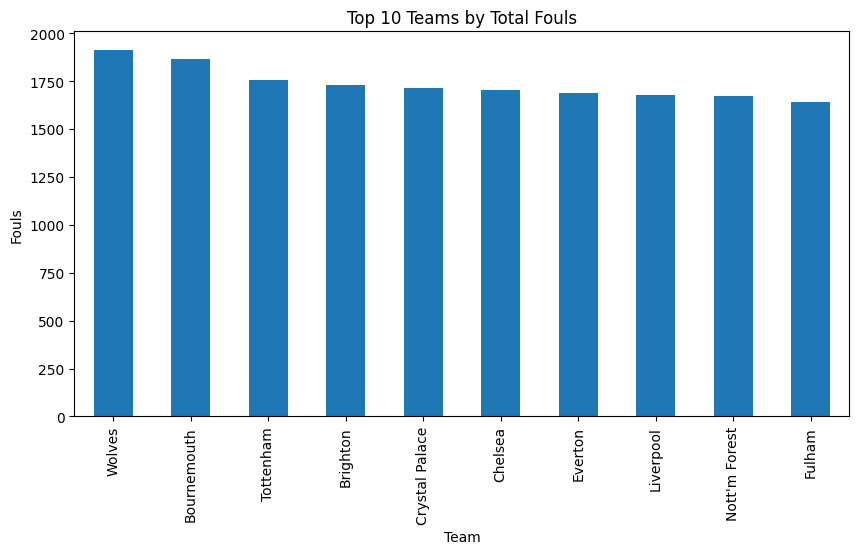

In [68]:
team_fouls.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Teams by Total Fouls")
plt.ylabel("Fouls")
plt.show()

AVERAGE FOULS

In [70]:
home_matches = data["HomeTeam"].value_counts()

away_matches = data["AwayTeam"].value_counts()

matches_played = (
    home_matches + away_matches
)

avg_fouls = (team_fouls/ matches_played).sort_values(ascending=False)
avg_fouls.head(10)

Wolves            12.592105
Bournemouth       12.289474
Southampton       11.697368
Luton             11.657895
Tottenham         11.559211
Brighton          11.388158
Ipswich           11.315789
Crystal Palace    11.296053
Leeds             11.236842
Chelsea           11.210526
dtype: float64

In [71]:
home_foul_mean = data["HF"].mean()

away_foul_mean = data["AF"].mean()

print("Home Fouls:", home_foul_mean)
print("Away Fouls:", away_foul_mean)

Home Fouls: 10.696052631578947
Away Fouls: 11.136184210526316


In [72]:
home_avg = data.groupby('HomeTeam')['HF'].mean()

away_avg = data.groupby("AwayTeam")['AF'].mean()

foul_difference = (away_avg - home_avg).sort_values(ascending=False)
foul_difference.head(10)

AwayTeam
Ipswich          2.210526
Southampton      1.657895
Brentford        1.486842
Burnley          1.184211
Fulham           1.039474
Everton          1.000000
Chelsea          0.894737
Sunderland       0.789474
Wolves           0.684211
Nott'm Forest    0.618421
dtype: float64

In [73]:
t_stat, p_value = ttest_ind(
    data["HF"],
    data["AF"]
)

print("p-value:", p_value)

p-value: 0.00045763844225843865


The difference between home and away
fouls is statistically significant.

#### AGGRESSION INDEX

In [76]:
team_aggression = (
    team_fouls / matches_played
)
scaler = MinMaxScaler()

aggression_score = scaler.fit_transform(
    team_aggression.values.reshape(-1,1)
)